In [30]:
#Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

In [42]:
csv = 'mergedworms2.csv'# Read the CSV file
data = pd.read_csv(csv)

np.random.seed(42)

## Lifespan Estimation

In [43]:
def predict_lifespan(data, model_select="linear", test_size=0.2, random_state=42):
    """
    Predict the lifespan of worms based on behavioral data.

    Args:
        df: DataFrame containing the dataset.
        model_select: Choice of regression model ('linear', 'random_forest', 'xgboost').
        test_size: Fraction of data to use as test set.
        random_state: Seed for reproducibility.

    Returns:
        None (prints evaluation metrics and feature importances for tree-based models).
    """
    df = data.copy()
    # csv = 'mergedworms.csv'# Read the CSV file
    # df = pd.read_csv(csv)


    # Preprocess lifespan (convert from hours to days)
    df['lifespan'] = df['lifespan'] / 24

    # Extract features (X), target (y), and groups (worm_id)
    # X = df.drop(columns=['id', 'worm_id', 'lifespan', 'average_distance_per_frame', 'maximal_distance_traveled', 'average_acceleration'])
    X = df.drop(columns = ['id','lifespan', 'worm_id'])
    y = df['lifespan']
    groups = df['worm_id']

    # Split the dataset into training and testing based on worm_id grouping
    gkf = GroupKFold(n_splits=int(1 / test_size))
    train_idx, test_idx = next(gkf.split(X, y, groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # sample imputing (NEED TO IMPROVE) -- ONLY TEMPORARY
    if np.isnan(X_train).any().any() or np.isnan(X_test).any().any():
        # Impute missing values with the median
        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(X_train)
        X_test = imputer.fit_transform(X_test)

    # Initialize the model
    if model_select == "linear":
        model = LinearRegression()
    elif model_select == "random_forest":
        model = RandomForestRegressor(random_state=random_state)
    elif model_select == "xgboost":
        model = XGBRegressor(random_state=random_state, n_estimators=100, learning_rate=0.05)
    else:
        raise Exception("Invalid model selected. Options are 'linear', 'random_forest', 'xgboost'.")

    # Scale features for linear models
    if model_select == "linear":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Train the model
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")

    # Feature importance for tree-based models
    if model_select in ["random_forest", "xgboost"]:
        importances = model.feature_importances_
        feature_importances = sorted(zip(X.columns, importances), key=lambda x: -x[1])
        print("\nFeature Importances:")
        for feature, importance in feature_importances:
            print(f"{feature}: {importance:.4f}")

    import matplotlib.pyplot as plt
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.xlabel("Actual Lifespan (days)")
    plt.ylabel("Predicted Lifespan (days)")
    plt.title("Predicted vs. Actual Lifespan")
    plt.show()

    print("y_pred max min", y_pred.max, y_pred.min)
    print("y_test max min", y_test.max, y_test.min)

    return model, mse, r2

Mean Squared Error: 6.81
R^2 Score: -0.09


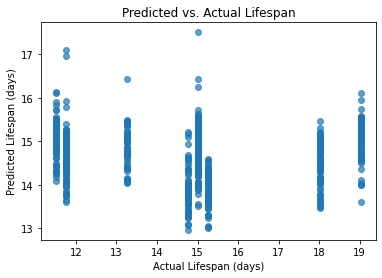

y_pred [14.1982565  14.00677782 13.79816936 13.51810605 13.93211705 13.88705598
 14.2117888  13.56845698 13.90800266 13.97404619 13.95576975 14.03578935
 14.55280011 14.70753537 14.23455928 14.08474604 14.39275321 14.48786673
 14.36370462 14.45826288 14.42912651 14.53291037 14.29214809 14.49113039
 14.29667237 14.27345866 14.8468718  14.22495343 14.64528575 14.33369933
 14.60855494 14.66969641 15.23466792 14.73087675 14.54724564 14.72580221
 14.59172426 14.87467508 14.75317213 14.89963714 14.6779495  14.59082059
 14.75873144 14.81504759 14.64974704 14.66612025 14.36478404 14.50064465
 14.49071742 16.25226248 14.21518615 14.50015632 14.3453943  14.42138412
 14.33415017 14.58410157 14.6709339  14.46134822 14.67286525 14.91541912
 14.75042918 14.69904737 14.62635973 14.54297556 14.55636562 14.53504455
 14.557804   14.5975688  14.65152744 14.61370094 14.66652908 15.4752551
 14.69763725 14.64087634 14.6933973  14.71443925 14.71650792 14.77540353
 15.47554665 15.10534852 15.17764901 14.94189

In [44]:
model, mse, r2 = predict_lifespan(data)

Mean Squared Error: 7.44
R^2 Score: -0.19

Feature Importances:
average_angular_speed: 0.1310
total_distance_traveled: 0.1250
maximal_distance_traveled: 0.1232
roaming_fraction: 0.0759
std/mean: 0.0712
drugged: 0.0677
time_elapsed_(hours): 0.0676
average_acceleration: 0.0605
std_speed: 0.0590
average_change_in_pixels: 0.0568
group: 0.0513
distance_traveled_bin: 0.0462
average_distance_per_frame: 0.0323
average_speed: 0.0322


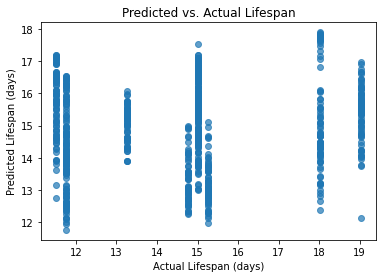

y_pred [14.39356435 15.12740023 15.06556944 16.78726806 15.89072778 14.59398148
 15.22248843 15.73079722 15.53618333 13.84662963 14.92441736 16.32486181
 14.78184074 14.80690602 15.75587361 14.28985764 15.60744144 15.78737778
 15.55191551 15.39866528 15.91675162 15.80454815 16.65895741 15.39177222
 15.57123218 16.32466042 16.05367639 13.93333079 15.85181921 14.91160694
 16.04715949 16.98122407 14.98812639 16.44361644 15.35971042 15.78410926
 15.54784398 15.92667361 15.24720741 15.33088287 15.46679398 15.29202269
 15.27277477 15.51713125 15.47805625 15.12890602 15.62752037 15.38888148
 15.31768981 15.07928681 13.80275417 14.90368264 13.57688009 14.18396991
 14.58080903 14.3215088  14.47431366 14.46654537 14.63099583 15.86340856
 14.85742106 14.16878681 14.13610162 14.55509676 14.64478009 14.88097222
 14.84971065 14.72407407 15.23434028 14.78027037 15.48950231 15.67186551
 15.90142361 15.95355741 16.03816181 15.75674977 16.11766204 15.76170556
 16.01337014 16.19768519 16.18988426 15.8398

In [45]:
model, mse, r2 = predict_lifespan(data, model_select="random_forest")

Mean Squared Error: 7.05
R^2 Score: -0.13

Feature Importances:
drugged: 0.2184
maximal_distance_traveled: 0.1113
time_elapsed_(hours): 0.0883
average_angular_speed: 0.0831
distance_traveled_bin: 0.0768
average_speed: 0.0701
roaming_fraction: 0.0676
std_speed: 0.0658
average_acceleration: 0.0648
std/mean: 0.0594
group: 0.0517
average_change_in_pixels: 0.0426
average_distance_per_frame: 0.0000
total_distance_traveled: 0.0000


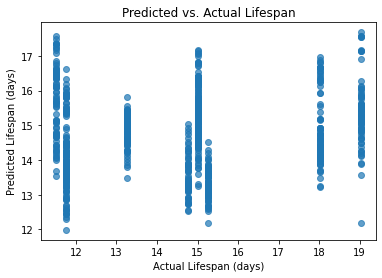

y_pred [14.484972  14.859006  15.460559  15.5089445 15.472165  14.598931
 13.859012  15.210376  15.328879  14.805585  15.45633   15.831836
 15.0558195 14.9568    15.211874  14.766423  15.445483  14.745653
 14.495485  14.8157015 15.192871  15.547714  15.706813  15.4161415
 15.502848  15.589327  15.464869  14.12288   15.161836  15.150758
 15.916572  15.743749  14.91261   15.926802  15.22778   15.595604
 16.021303  15.82776   15.407682  14.807756  14.792825  15.60684
 15.129543  15.554819  15.690784  15.262546  15.132541  15.333732
 15.313584  14.657829  14.359686  14.77151   14.292795  14.5429535
 14.459789  14.623853  14.7577305 14.848825  14.900133  15.805641
 15.515262  14.672972  14.714264  14.650433  14.672972  14.816919
 14.798766  14.851499  14.894013  14.515708  14.933286  14.908751
 15.267048  14.765754  15.059289  15.0597315 15.085953  14.724938
 15.295928  15.78625   15.677377  15.161305  15.381852  15.329459
 14.03655   14.13122   13.879187  14.520859  14.542443  14.5780115
 

In [46]:
model, mse, r2 = predict_lifespan(data, model_select="xgboost")

In [78]:
csv = 'mergedworms.csv'# Read the CSV file
data = pd.read_csv(csv)

aggregated_data = data.groupby("worm_id").agg({
    "worm_id": "first",
    "group": "first",  # Assuming group is constant per worm
    "average_speed": ["mean", "median", "min", "max"],
    "maximal_distance_traveled": "max",  # Keep max as it may capture peaks
    "average_change_in_pixels": ["mean", "std", "median", "min", "max"],
    "average_angular_speed": ["mean", "std", "min", "max"],
    "distance_traveled_bin": ["mean", "std"],
    "time_elapsed_(hours)": "max",  # Keep max as it's likely cumulative
    "std_speed": "mean",  # Capture average variability
    "std/mean": "mean",  # Keep mean of std/mean as a ratio metric
    "roaming_fraction": "mean",  # Capture average roaming behavior
    "lifespan": "first",  # Lifespan is constant per worm
    "drugged": "first"  # Assuming drugged is constant per worm
})
aggregated_data.columns = ["_".join(col).strip() for col in aggregated_data.columns]
aggregated_data.rename(columns={"lifespan_first": "lifespan", "worm_id_first": "worm_id"}, inplace=True)

In [82]:
# aggregated_data.columns
aggregated_data['lifespan']

worm_id
1     354.497222
2     498.496111
3     498.496111
4       0.001111
5     498.496111
6     426.496667
7       0.007778
8     498.496111
9     336.460000
10    498.496111
11    168.498333
12    300.488889
13    324.422222
14      0.448889
15     60.463333
16    354.497222
17    426.496667
18    270.500000
19     12.033333
20      0.463889
21     66.480000
22     72.403333
23    330.393889
24    222.500000
25     12.469444
26     24.482222
27    498.496111
28    426.496667
29     42.037778
30    426.496667
31    252.038889
32    384.473889
33     96.467778
34      0.043333
35    258.213333
36      0.007778
37    498.496111
38    288.463889
39    354.497222
40    426.496667
41      0.001111
42     90.027222
43      0.001111
44    396.005000
45    294.195556
46      0.495556
47     12.301111
48      0.105556
Name: lifespan, dtype: float64

In [80]:
# Check for high correlation and avoid duplicates
# Iterate through the upper triangle of the correlation matrix (to avoid duplicates)
correlation_matrix = aggregated_data.corr()

# Threshold for high correlation
threshold = 0.75

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):  # Upper triangle
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            correlation_value = correlation_matrix.iloc[i, j]
            print(f"Highly correlated: {col1} and {col2} with correlation {correlation_value:.2f}")

Highly correlated: average_speed_mean and average_speed_max with correlation 0.78
Highly correlated: average_speed_mean and distance_traveled_bin_mean with correlation 0.79
Highly correlated: average_speed_mean and distance_traveled_bin_std with correlation 0.79
Highly correlated: average_speed_median and distance_traveled_bin_mean with correlation 0.78
Highly correlated: maximal_distance_traveled_max and distance_traveled_bin_mean with correlation 0.86
Highly correlated: average_change_in_pixels_mean and average_change_in_pixels_max with correlation 0.79
Highly correlated: distance_traveled_bin_mean and distance_traveled_bin_std with correlation 0.76


Mean Squared Error: 126.05
R^2 Score: -1.90

Feature Importances:
average_change_in_pixels_max: 0.1590
average_angular_speed_max: 0.1263
average_change_in_pixels_mean: 0.1247
maximal_distance_traveled_max: 0.0983
average_angular_speed_std: 0.0969
group_first: 0.0853
average_speed_max: 0.0750
average_change_in_pixels_std: 0.0628
distance_traveled_bin_std: 0.0612
std_speed_mean: 0.0280
average_speed_median: 0.0252
average_change_in_pixels_median: 0.0166
average_angular_speed_min: 0.0134
roaming_fraction_mean: 0.0092
time_elapsed_(hours)_max: 0.0070
average_speed_mean: 0.0068
average_speed_min: 0.0041
average_change_in_pixels_min: 0.0001
average_angular_speed_mean: 0.0000
distance_traveled_bin_mean: 0.0000
std/mean_mean: 0.0000
drugged_first: 0.0000


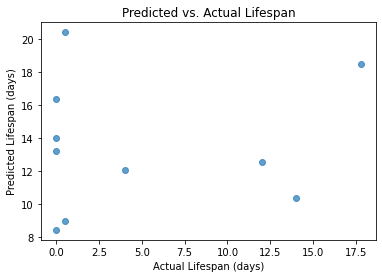

y_pred [16.400007  10.377701  13.219747   9.0119295 20.437971  18.501202
 12.082437  12.597029  14.055004   8.453772 ]
y_test worm_id
4      0.000046
9     14.019167
14     0.018704
19     0.501389
25     0.519560
28    17.770694
33     4.019491
38    12.019329
43     0.000046
48     0.004398
Name: lifespan, dtype: float64


In [81]:
model, mse, r2 = predict_lifespan(aggregated_data, model_select="xgboost")

In [28]:
csv2 = 'mergedworms_final.csv'# Read the CSV file
data2 = pd.read_csv(csv2)



In [29]:
data2.isna().sum()

Unnamed: 0                    0
group                         0
average_speed                 0
average_distance_per_frame    0
maximal_distance_traveled     0
average_change_in_pixels      0
average_angular_speed         0
distance_travaled             0
distance_travaled.1           0
average_change_speed          0
time_elapsed_(hours)          0
std_speed                     4
std/mean                      4
roaming_fraction              0
lifespan                      0
drugged                       0
worm_id                       0
dtype: int64

In [25]:
data2.shape

(312, 17)